# ***Load Dataset***

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


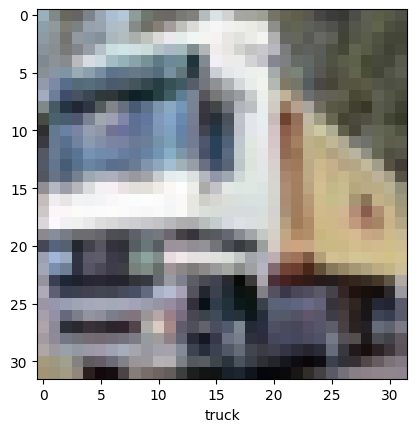

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
IMG_INDEX = 1
plt.imshow(train_images[IMG_INDEX], cmap=plt.cm.binary)
plt.xlabel(class_name[train_labels[IMG_INDEX][0]])
plt.show()

# **CNN Architecture**

In [8]:
model = models.Sequential()
#Input Layer: 32 filters of size 3x3 with activation relu
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
#Max Pooling using 2x2 samples and stride of 2
model.add(layers.MaxPooling2D((2, 2)))
#Additional Layers but the feature map becomes the input and we use 64 filters
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Dense Layer**

In [9]:
model.add(layers.Flatten()) #Classify based on features
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()
train_images.shape
#

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

(50000, 32, 32, 3)

# **Training**

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
model.evaluate(test_images, test_labels, verbose=2)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.3321 - loss: 1.8017 - val_accuracy: 0.5122 - val_loss: 1.3267
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.5389 - loss: 1.2840 - val_accuracy: 0.5769 - val_loss: 1.1864
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.6168 - loss: 1.0884 - val_accuracy: 0.6456 - val_loss: 1.0220
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.6556 - loss: 0.9825 - val_accuracy: 0.6586 - val_loss: 0.9836
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6818 - loss: 0.9063 - val_accuracy: 0.6717 - val_loss: 0.9315
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7074 - loss: 0.8304 - val_accuracy: 0.6789 - val_loss: 0.9138
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.7245 - loss: 0.7864 - val_accuracy: 0.6912 - val_loss: 0.8872
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.7428 -

# **Data Augmentation**
Add 4 rotations to a image and save in test.jpeg

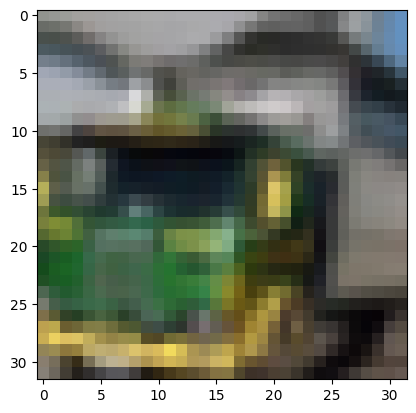

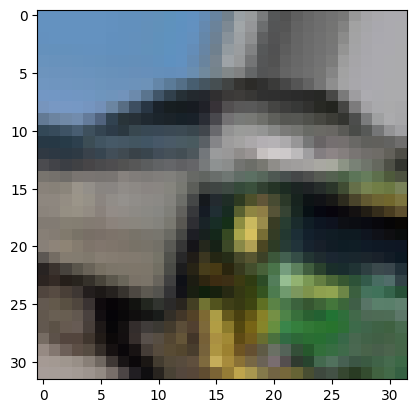

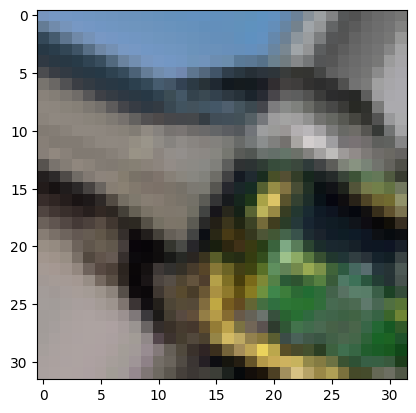

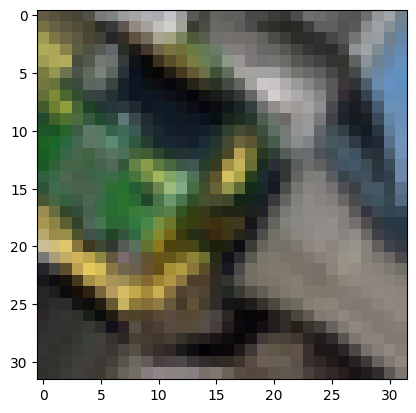

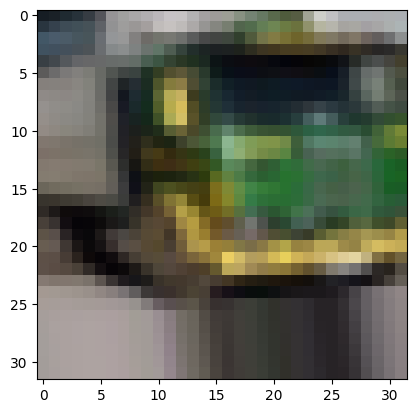

In [22]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=40,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest')
test_img = train_images[14]
img = image.img_to_array(test_img)
img = img.reshape((1,) + img.shape)
i = 0
for batch in datagen.flow(img, save_prefix='test', save_format='jpeg'):
  plt.figure(i)
  plot = plt.imshow(image.img_to_array(batch[0]))
  i += 1
  if i > 4:
    break
plt.show()

# ***Fine Tuning***

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
keras = tf.keras
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)
get_label_name = metadata.features['label'].int2str #Create a function object that we can use to get labels

IMG_SIZE = 160
def format_example(image, label): #Resize img to 160x160
  image = tf.cast(image, tf.float32)
  image = (image/127.5) - 1
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  return image, label
train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000
train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
#Load Pretrained Model
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False, #Do not include classifier
                                               weights='imagenet')
#base_model.summary() #CNN Model with all their layers
base_model.trainable = False #Freeze the layers. No need to retrain the layers.
global_average_layer = tf.keras.layers.GlobalAveragePooling2D() #Average Pooling to a single 1280 element vector
prediction_layer = keras.layers.Dense(1) #2 classes (Cat, Dog)
model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  prediction_layer
])
model.summary() #Fine-tuned CNN model

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Training the Model**

In [36]:
learning_rate = 0.001
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate), #Optimizer = GD and BP
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), #Binary Cross Error
              metrics=['accuracy'])
initial_epochs = 3
validation_steps = 20
loss0,accuracy0 = model.evaluate(validation_batches, steps = validation_steps)
history = model.fit(train_batches,
                    epochs=initial_epochs,
                    validation_data=validation_batches)
print(history.history['accuracy'])

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - accuracy: 0.4915 - loss: 0.7953
Epoch 1/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 285s 482ms/step - accuracy: 0.9473 - loss: 0.1244 - val_accuracy: 0.9819 - val_loss: 0.0477
Epoch 2/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 277s 474ms/step - accuracy: 0.9842 - loss: 0.0429 - val_accuracy: 0.9807 - val_loss: 0.0487
Epoch 3/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 332s 491ms/step - accuracy: 0.9867 - loss: 0.0382 - val_accuracy: 0.9824 - val_loss: 0.0468
[0.9724341630935669, 0.983396053314209, 0.9850080609321594]


In [37]:
model.save("dogs_vs_cats.h5")  # we can save the model and reload it at anytime in the future
new_model = tf.keras.models.load_model('dogs_vs_cats.h5')

Object Detection API: https://github.com/tensorflow/models/tree/master/research/object_detection